# Network Event Delivery Backend Benchmark

This notebook benchmarks the sparse event-delivery kernel used by `braincell.Network.run(...)`. It compares the public `event_backend="scatter"` path against `event_backend="brainevent"` with selectable `brainevent.coomv` internal kernels.

The benchmark runs child Python processes so `JAX_PLATFORMS=cpu` or `JAX_PLATFORMS=cuda` is set before JAX is imported. CUDA cases are reported as skipped when the current session cannot see a GPU or driver.

The child-process code lives in `_network_event_backend_child.py`; the notebook only prepares benchmark cases, launches that script, and plots the returned JSON rows.

In [1]:
import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")


repo_root = find_repo_root()
python_exe = os.environ.get("BENCHMARK_PYTHON", sys.executable)
print("repo_root:", repo_root)
print("benchmark python:", python_exe)


repo_root: /home/swl/braincell
benchmark python: /home/swl/anaconda3/envs/braincell_311/bin/python


In [2]:
CASES = [
    {"name": "100x100 / 1k edges", "n_pre": 100, "n_post": 100, "edges": 1_000},
    {"name": "1000x1000 / 10k edges", "n_pre": 2_000, "n_post": 2_000, "edges": 10_000},
    {"name": "2000x2000 / 20k edges", "n_pre": 5_000, "n_post": 5_000, "edges": 20_000},
    {"name": "2000x2000 / 100k edges", "n_pre": 5_000, "n_post": 5_000, "edges": 200_000},
]

CPU_MODES = [
    {"label": "scatter", "event_backend": "scatter", "brainevent_backend": None},
    {"label": "brainevent:jax_raw", "event_backend": "brainevent", "brainevent_backend": "jax_raw"},
]

CUDA_MODES = [
    {"label": "scatter", "event_backend": "scatter", "brainevent_backend": None},
    {"label": "brainevent:jax_raw", "event_backend": "brainevent", "brainevent_backend": "jax_raw"},
    {"label": "brainevent:cuda_raw", "event_backend": "brainevent", "brainevent_backend": "cuda_raw"},
    {"label": "brainevent:cusparse", "event_backend": "brainevent", "brainevent_backend": "cusparse"},
]

WARMUP = 2
REPEATS = 5
N_ACTIVE = 1
SEED = 123


In [3]:
child_script = repo_root / "examples" / "multi_compartment" / "_network_event_backend_child.py"
if not child_script.exists():
    raise FileNotFoundError(child_script)


def run_one(platform, mode, case):
    env = os.environ.copy()
    env["JAX_PLATFORMS"] = platform
    env.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
    cfg = {
        **case,
        **mode,
        "platform": platform,
        "warmup": WARMUP,
        "repeats": REPEATS,
        "n_active": N_ACTIVE,
        "seed": SEED,
    }
    proc = subprocess.run(
        [python_exe, str(child_script)],
        input=json.dumps(cfg),
        text=True,
        capture_output=True,
        env=env,
        cwd=str(repo_root),
    )
    json_lines = [line for line in proc.stdout.splitlines() if line.strip().startswith("{")]
    if json_lines:
        result = json.loads(json_lines[-1])
    else:
        result = {"status": "error", "error": "child produced no JSON"}
    if proc.stderr.strip():
        result["stderr_tail"] = proc.stderr.strip().splitlines()[-8:]
    result.update({
        "platform": platform,
        "backend": mode["label"],
        "case": case["name"],
        "n_pre": case["n_pre"],
        "n_post": case["n_post"],
        "edges": case["edges"],
    })
    return result

In [4]:
rows = []
for platform, modes in (("cpu", CPU_MODES), ("cuda", CUDA_MODES)):
    for case in CASES:
        for mode in modes:
            row = run_one(platform, mode, case)
            rows.append(row)
            if row["status"] == "ok":
                print(f"{platform:4s} {case['name']:24s} {mode['label']:20s} {row['median_ms']:.3f} ms")
            else:
                print(f"{platform:4s} {case['name']:24s} {mode['label']:20s} {row['status']}: {row.get('error', '')}")

rows


cpu  100x100 / 1k edges       scatter              0.065 ms
cpu  100x100 / 1k edges       brainevent:jax_raw   0.045 ms
cpu  1000x1000 / 10k edges    scatter              0.173 ms
cpu  1000x1000 / 10k edges    brainevent:jax_raw   0.186 ms
cpu  2000x2000 / 20k edges    scatter              0.334 ms
cpu  2000x2000 / 20k edges    brainevent:jax_raw   0.139 ms
cpu  2000x2000 / 100k edges   scatter              0.933 ms
cpu  2000x2000 / 100k edges   brainevent:jax_raw   0.928 ms
cuda 100x100 / 1k edges       scatter              0.172 ms
cuda 100x100 / 1k edges       brainevent:jax_raw   0.199 ms
cuda 100x100 / 1k edges       brainevent:cuda_raw  0.157 ms
cuda 100x100 / 1k edges       brainevent:cusparse  0.201 ms
cuda 1000x1000 / 10k edges    scatter              0.165 ms
cuda 1000x1000 / 10k edges    brainevent:jax_raw   0.169 ms
cuda 1000x1000 / 10k edges    brainevent:cuda_raw  0.176 ms
cuda 1000x1000 / 10k edges    brainevent:cusparse  0.179 ms
cuda 2000x2000 / 20k edges    scatter   

[{'status': 'ok',
  'median_ms': 0.0650720321573317,
  'min_ms': 0.05612900713458657,
  'std_ms': 0.019678705778663732,
  'output_sum': 32.40951156616211,
  'default_backend': 'cpu',
  'devices': ['cpu:0'],
  'platform': 'cpu',
  'backend': 'scatter',
  'case': '100x100 / 1k edges',
  'n_pre': 100,
  'n_post': 100,
  'edges': 1000},
 {'status': 'ok',
  'median_ms': 0.0452399835921824,
  'min_ms': 0.043278036173433065,
  'std_ms': 0.0029144394802867015,
  'output_sum': 32.40951156616211,
  'default_backend': 'cpu',
  'devices': ['cpu:0'],
  'platform': 'cpu',
  'backend': 'brainevent:jax_raw',
  'case': '100x100 / 1k edges',
  'n_pre': 100,
  'n_post': 100,
  'edges': 1000},
 {'status': 'ok',
  'median_ms': 0.1731140073388815,
  'min_ms': 0.08613301906734705,
  'std_ms': 0.04596025555698303,
  'output_sum': 553.8274536132812,
  'default_backend': 'cpu',
  'devices': ['cpu:0'],
  'platform': 'cpu',
  'backend': 'scatter',
  'case': '1000x1000 / 10k edges',
  'n_pre': 2000,
  'n_post': 20

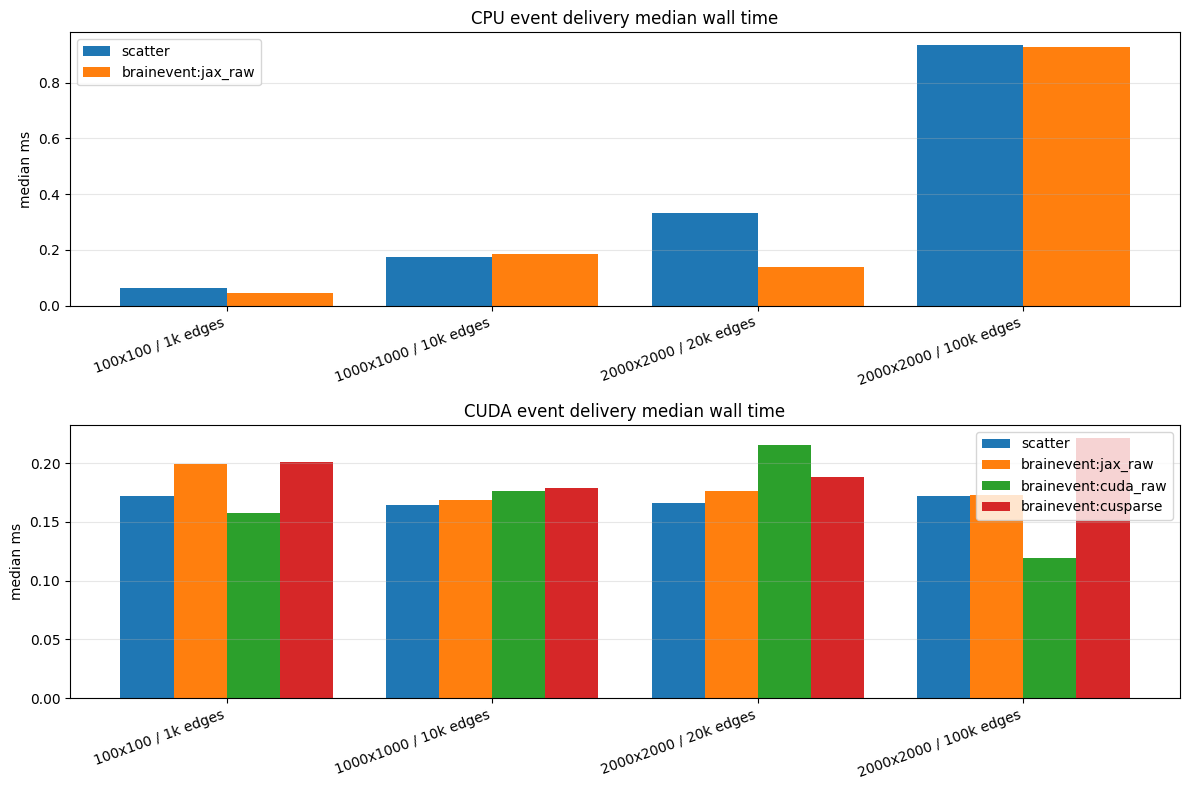

In [5]:
ok_rows = [row for row in rows if row["status"] == "ok"]
if not ok_rows:
    raise RuntimeError("No benchmark rows completed successfully.")

platforms = list(dict.fromkeys(row["platform"] for row in ok_rows))
fig, axes = plt.subplots(len(platforms), 1, figsize=(12, 4 * len(platforms)), squeeze=False)

for ax, platform in zip(axes[:, 0], platforms):
    platform_rows = [row for row in ok_rows if row["platform"] == platform]
    cases = list(dict.fromkeys(row["case"] for row in platform_rows))
    backends = list(dict.fromkeys(row["backend"] for row in platform_rows))
    x = np.arange(len(cases), dtype=float)
    width = 0.8 / max(len(backends), 1)
    for backend_index, backend in enumerate(backends):
        values = []
        for case in cases:
            match = [row for row in platform_rows if row["case"] == case and row["backend"] == backend]
            values.append(match[0]["median_ms"] if match else np.nan)
        offset = (backend_index - (len(backends) - 1) / 2) * width
        ax.bar(x + offset, values, width=width, label=backend)
    ax.set_title(f"{platform.upper()} event delivery median wall time")
    ax.set_ylabel("median ms")
    ax.set_xticks(x)
    ax.set_xticklabels(cases, rotation=20, ha="right")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()

fig.tight_layout()
plt.show()


In [6]:
print("Completed rows:")
for row in ok_rows:
    print(
        f"{row['platform']:4s} {row['case']:24s} {row['backend']:20s} "
        f"median={row['median_ms']:.3f} ms min={row['min_ms']:.3f} ms std={row['std_ms']:.3f} ms"
    )

skipped_or_failed = [row for row in rows if row["status"] != "ok"]
if skipped_or_failed:
    print("\nSkipped or failed rows:")
    for row in skipped_or_failed:
        print(f"{row['platform']:4s} {row['case']:24s} {row['backend']:20s} {row['status']}: {row.get('error', '')}")


Completed rows:
cpu  100x100 / 1k edges       scatter              median=0.065 ms min=0.056 ms std=0.020 ms
cpu  100x100 / 1k edges       brainevent:jax_raw   median=0.045 ms min=0.043 ms std=0.003 ms
cpu  1000x1000 / 10k edges    scatter              median=0.173 ms min=0.086 ms std=0.046 ms
cpu  1000x1000 / 10k edges    brainevent:jax_raw   median=0.186 ms min=0.103 ms std=0.047 ms
cpu  2000x2000 / 20k edges    scatter              median=0.334 ms min=0.165 ms std=0.069 ms
cpu  2000x2000 / 20k edges    brainevent:jax_raw   median=0.139 ms min=0.134 ms std=0.093 ms
cpu  2000x2000 / 100k edges   scatter              median=0.933 ms min=0.887 ms std=0.029 ms
cpu  2000x2000 / 100k edges   brainevent:jax_raw   median=0.928 ms min=0.825 ms std=0.160 ms
cuda 100x100 / 1k edges       scatter              median=0.172 ms min=0.163 ms std=0.014 ms
cuda 100x100 / 1k edges       brainevent:jax_raw   median=0.199 ms min=0.167 ms std=1.270 ms
cuda 100x100 / 1k edges       brainevent:cuda_raw  med